# Tugas Besar Pembelajaran Mesin WAKNN - Kel 8

**Link Dataset: https://www.kaggle.com/datasets/nikhil7280/weather-type-classification**/

## Menyiapkan Library

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

## Gathering Data

**Membaca data `weather_classification_data.csv`**

In [2]:
df = pd.read_csv('../dataset/weather_classification_data.csv')
df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## Exploratory Data Analysis

**Melihat Struktur Data `df`**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13200 entries, 0 to 13199
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Temperature           13200 non-null  float64
 1   Humidity              13200 non-null  int64  
 2   Wind Speed            13200 non-null  float64
 3   Precipitation (%)     13200 non-null  float64
 4   Cloud Cover           13200 non-null  object 
 5   Atmospheric Pressure  13200 non-null  float64
 6   UV Index              13200 non-null  int64  
 7   Season                13200 non-null  object 
 8   Visibility (km)       13200 non-null  float64
 9   Location              13200 non-null  object 
 10  Weather Type          13200 non-null  object 
dtypes: float64(5), int64(2), object(4)
memory usage: 1.1+ MB


Insight:
- Jumlah data untuk semua fitur, sama. Artinya tidak ada missing value
- Tipe data untuk setiap fitur sudah benar
- Jumlah baris sebanyak 13.200 dengan 11 kolom

**Cek Descriptive Statistic**

In [4]:
df.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


**Cek Missing Value**

In [5]:
df.isna().sum()

Temperature             0
Humidity                0
Wind Speed              0
Precipitation (%)       0
Cloud Cover             0
Atmospheric Pressure    0
UV Index                0
Season                  0
Visibility (km)         0
Location                0
Weather Type            0
dtype: int64

Insight:
- Terbukti bahwa tidak ada data yang missing

**Cek Duplikasi Data**

In [6]:
print(f'Jumlah data duplikat: {df.duplicated().sum()} buah data')

Jumlah data duplikat: 0 buah data


### Univariate Analysis

In [7]:
# Pisahkan kolom numerik dan kategorikal
num_cols_univysis = ['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
cat_cols_univysis = ['Cloud Cover', 'Season', 'Location',  'Weather Type']

In [8]:
# Set tema visualisasi
sns.set_theme(style='whitegrid')

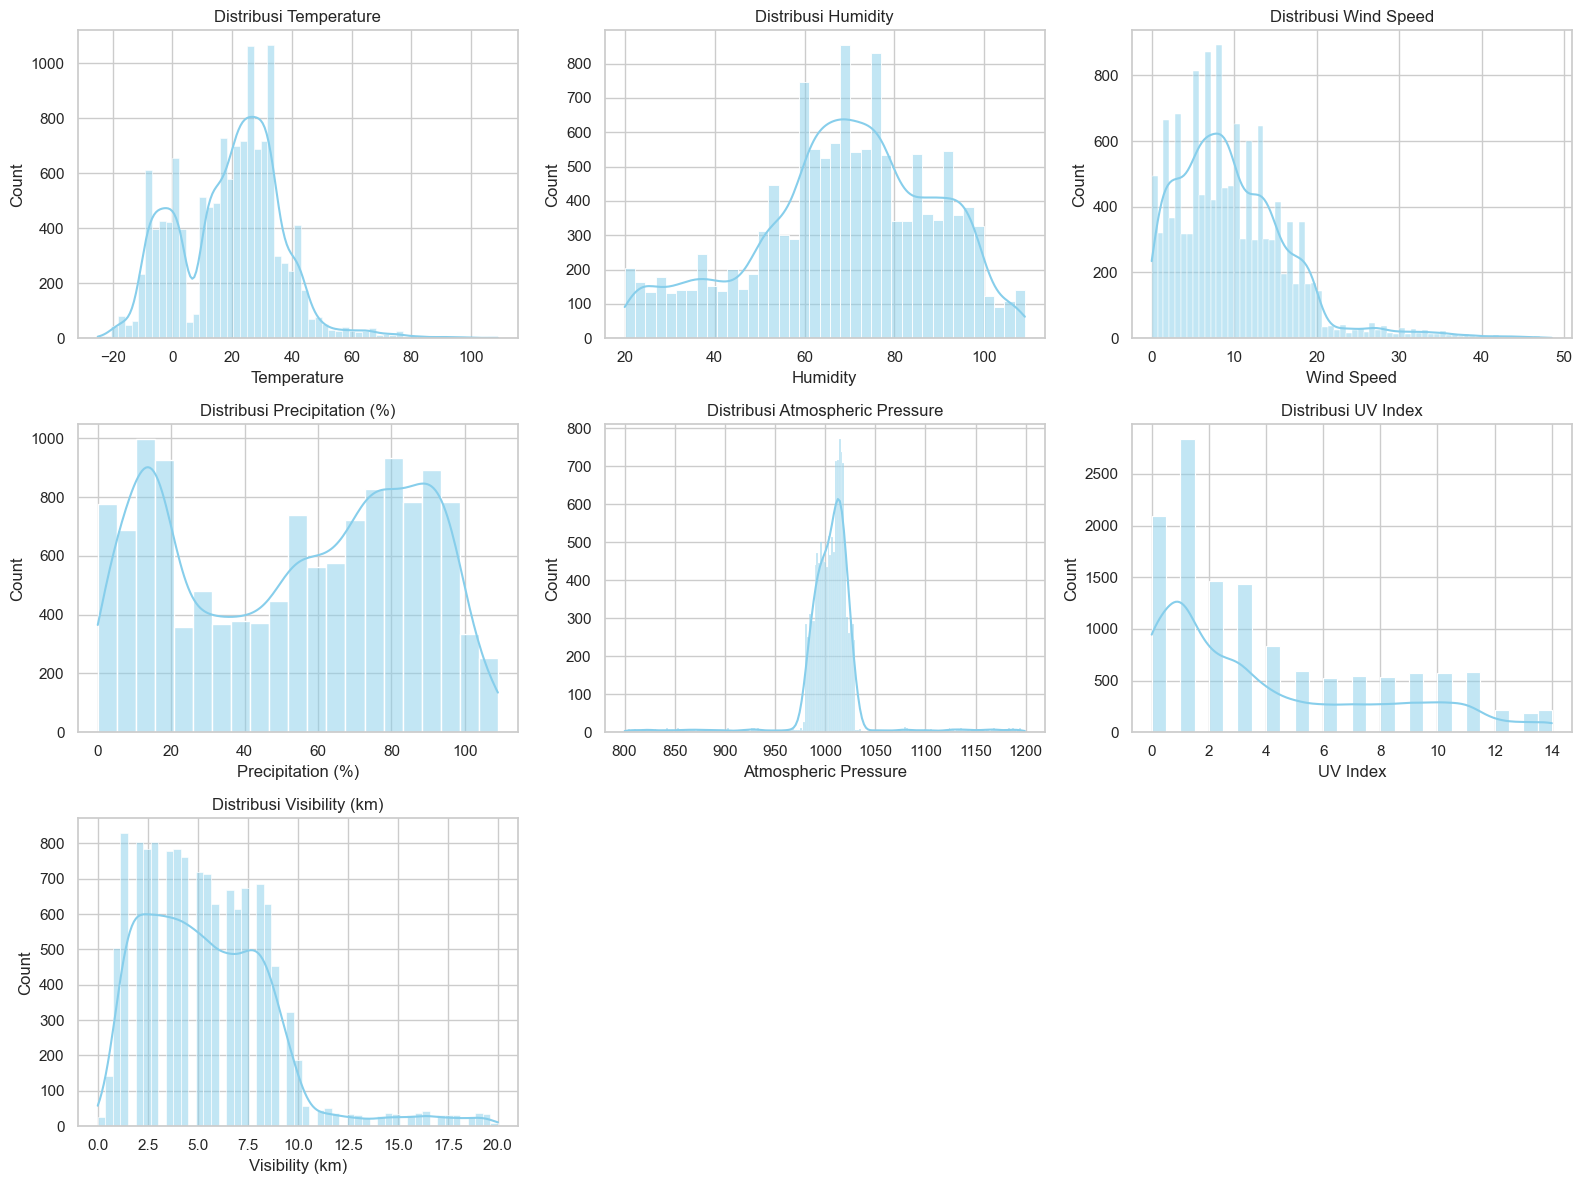

In [9]:
# Analisis Variabel Numerik - Melihat Distribusi Data
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols_univysis, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribusi {col}')
plt.tight_layout()
plt.show()

Insight:
- Pada histogram `Humidity`, terdapat beberapa data yang > 100%. Ini tidak masuk akal.
- Pada histogram `Temperature`, terdapat beberapa data suhu yang > 60 derajat. Ini sangat tidak wajar.
- Kedua hal itu harus dihapus pada proses **Preprocessing**

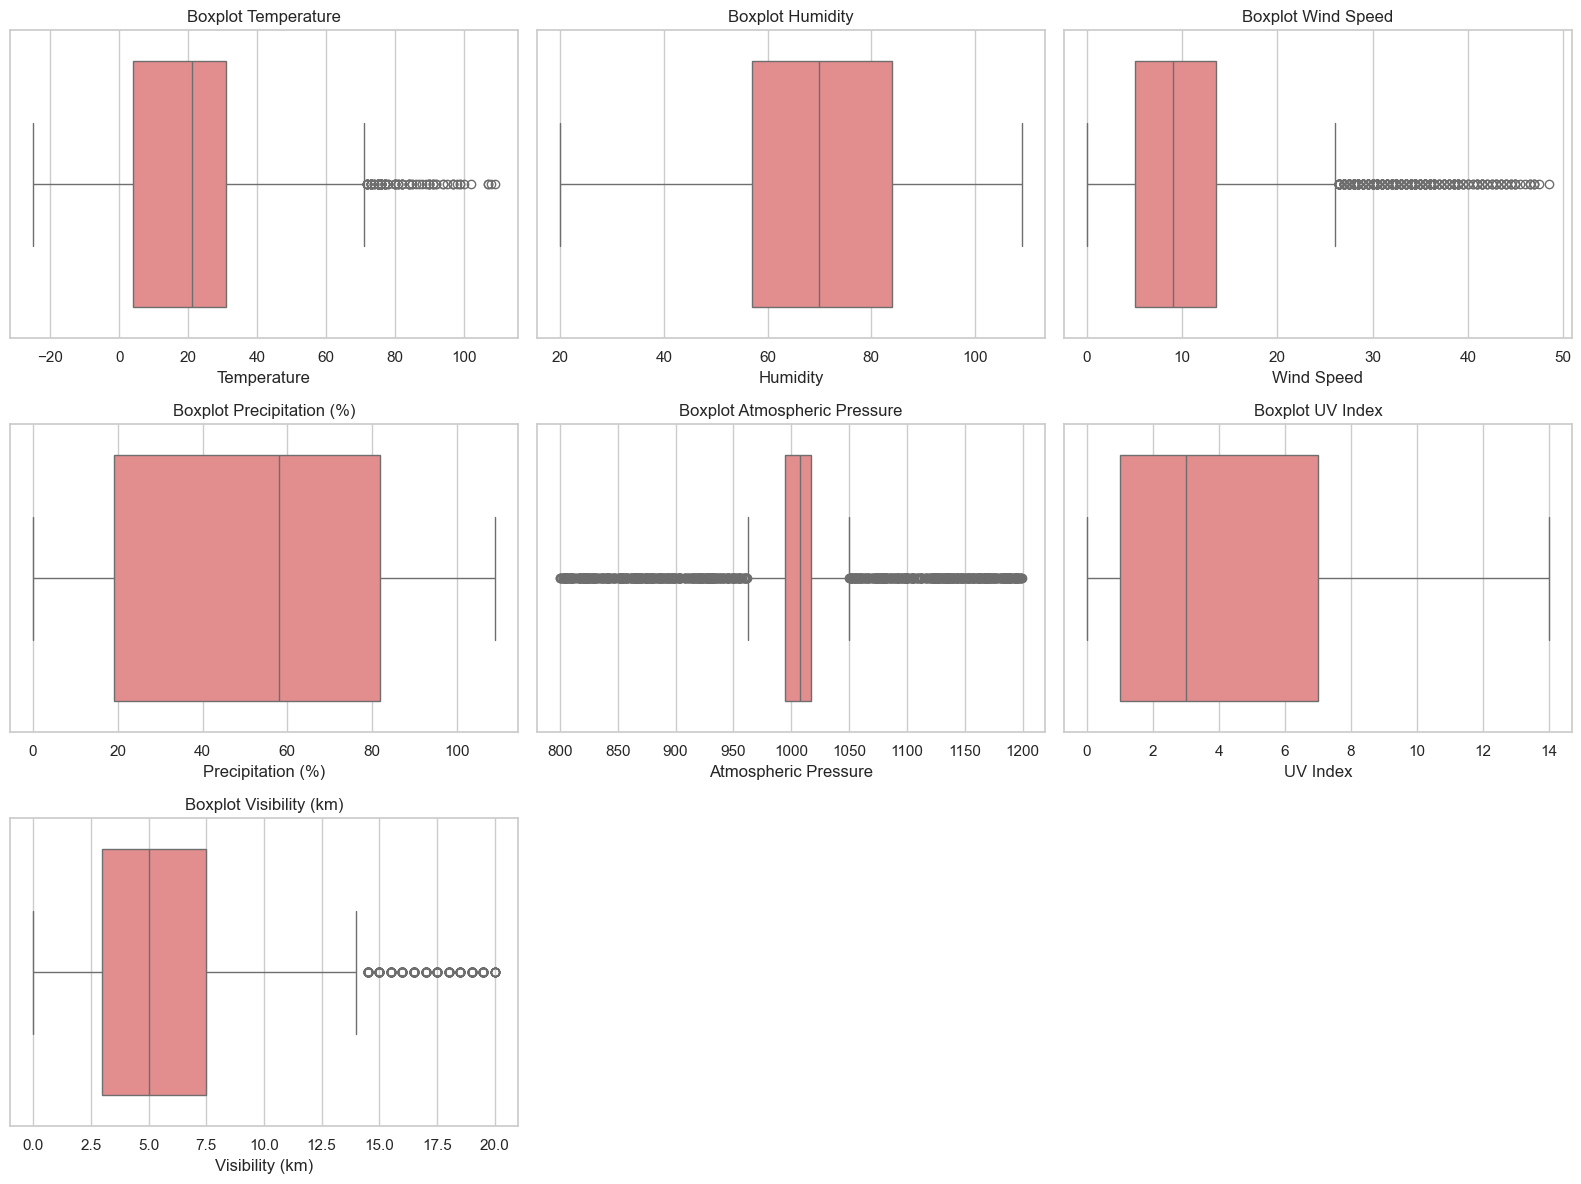

In [10]:
# Analisis Outlier
plt.figure(figsize=(16, 12))
for i, col in enumerate(num_cols_univysis, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(x=df[col], color='lightcoral')
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

Insight:
- Pada fitur `Temperature`, `Wind Speed`, dan `Atmoshperic Pressure` memiliki banyak sekali outlier. Ini perlu ditangani, karena algoritma `WAKNN` sensitif terhadap outlier
- Untuk fitur `Visibility` juga memiliki outlier, namun tidak se-ekstrem 3 fitur sebelumnya
- Sedangkan sisanya, memiliki kondisi data yang baik

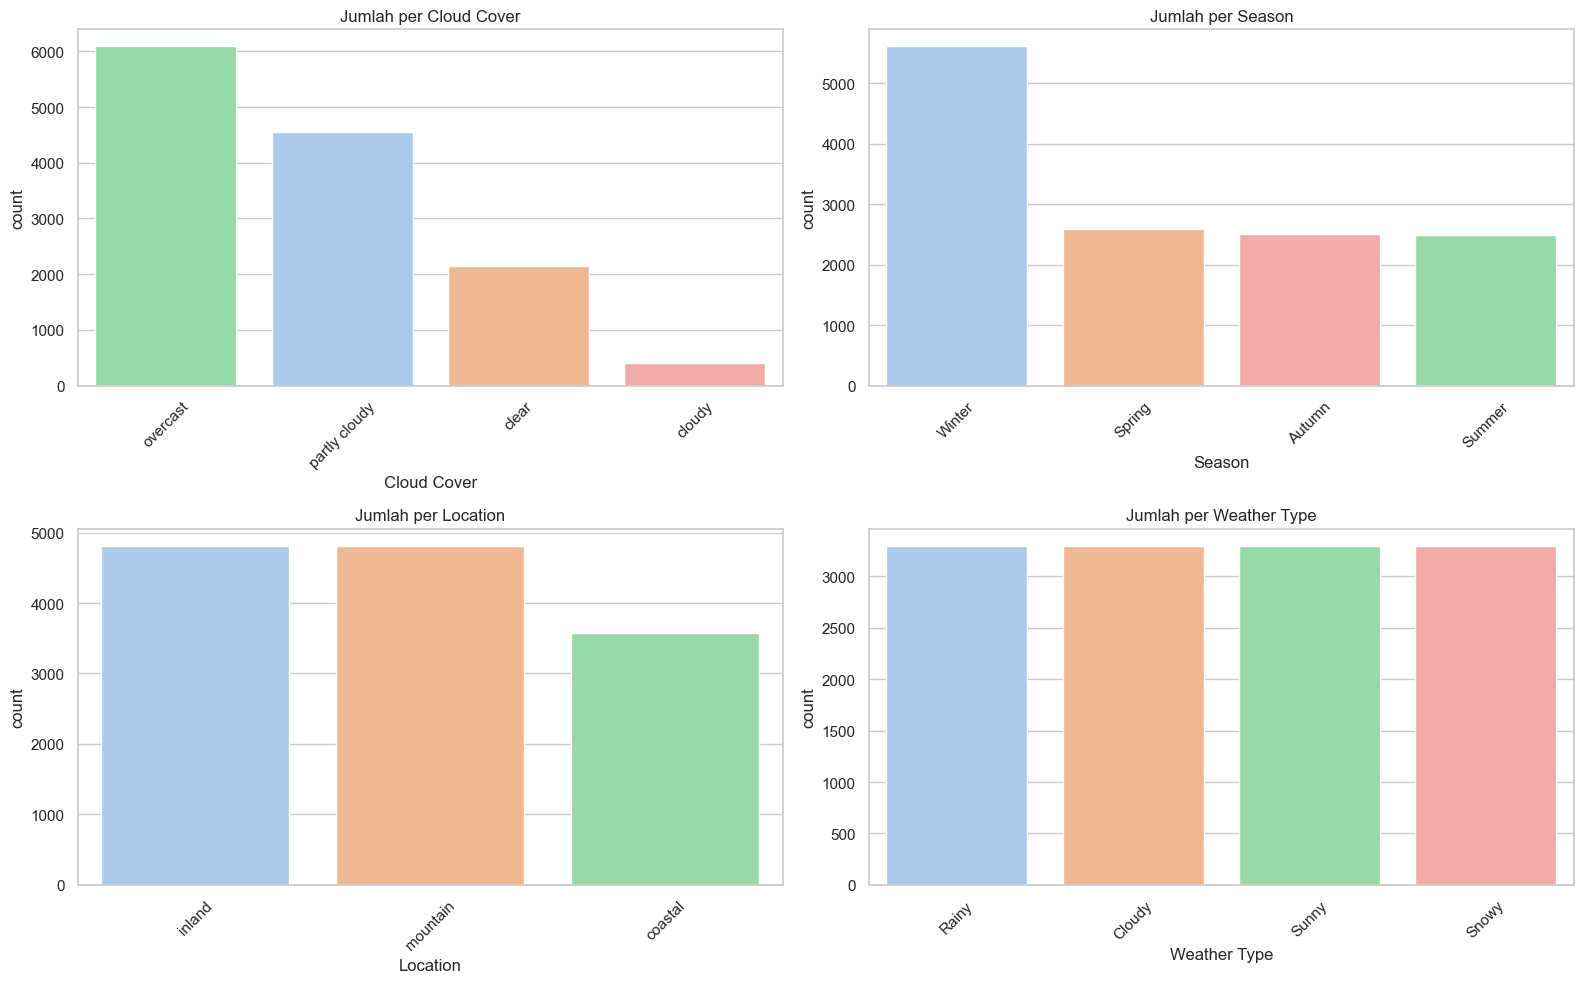

In [11]:
# Analisis Variabel Kategorikal - Melihat Frekuensi Kemunculan
plt.figure(figsize=(16, 10))
for i, col in enumerate(cat_cols_univysis, 1):
    plt.subplot(2, 2, i)
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, hue=col, palette='pastel', order=order, legend=False)
    plt.title(f'Jumlah per {col}')
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Insight:
- Dari sini terlihat bahwa untuk label atau fitur `Weather Type`, jumlah valuenya nya balance

### Bivariate & Multivariate Analysis

In [12]:
# Mengatur kolom
cat_cols_bivysis = ['Cloud Cover', 'Season', 'Location']
target = 'Weather Type'

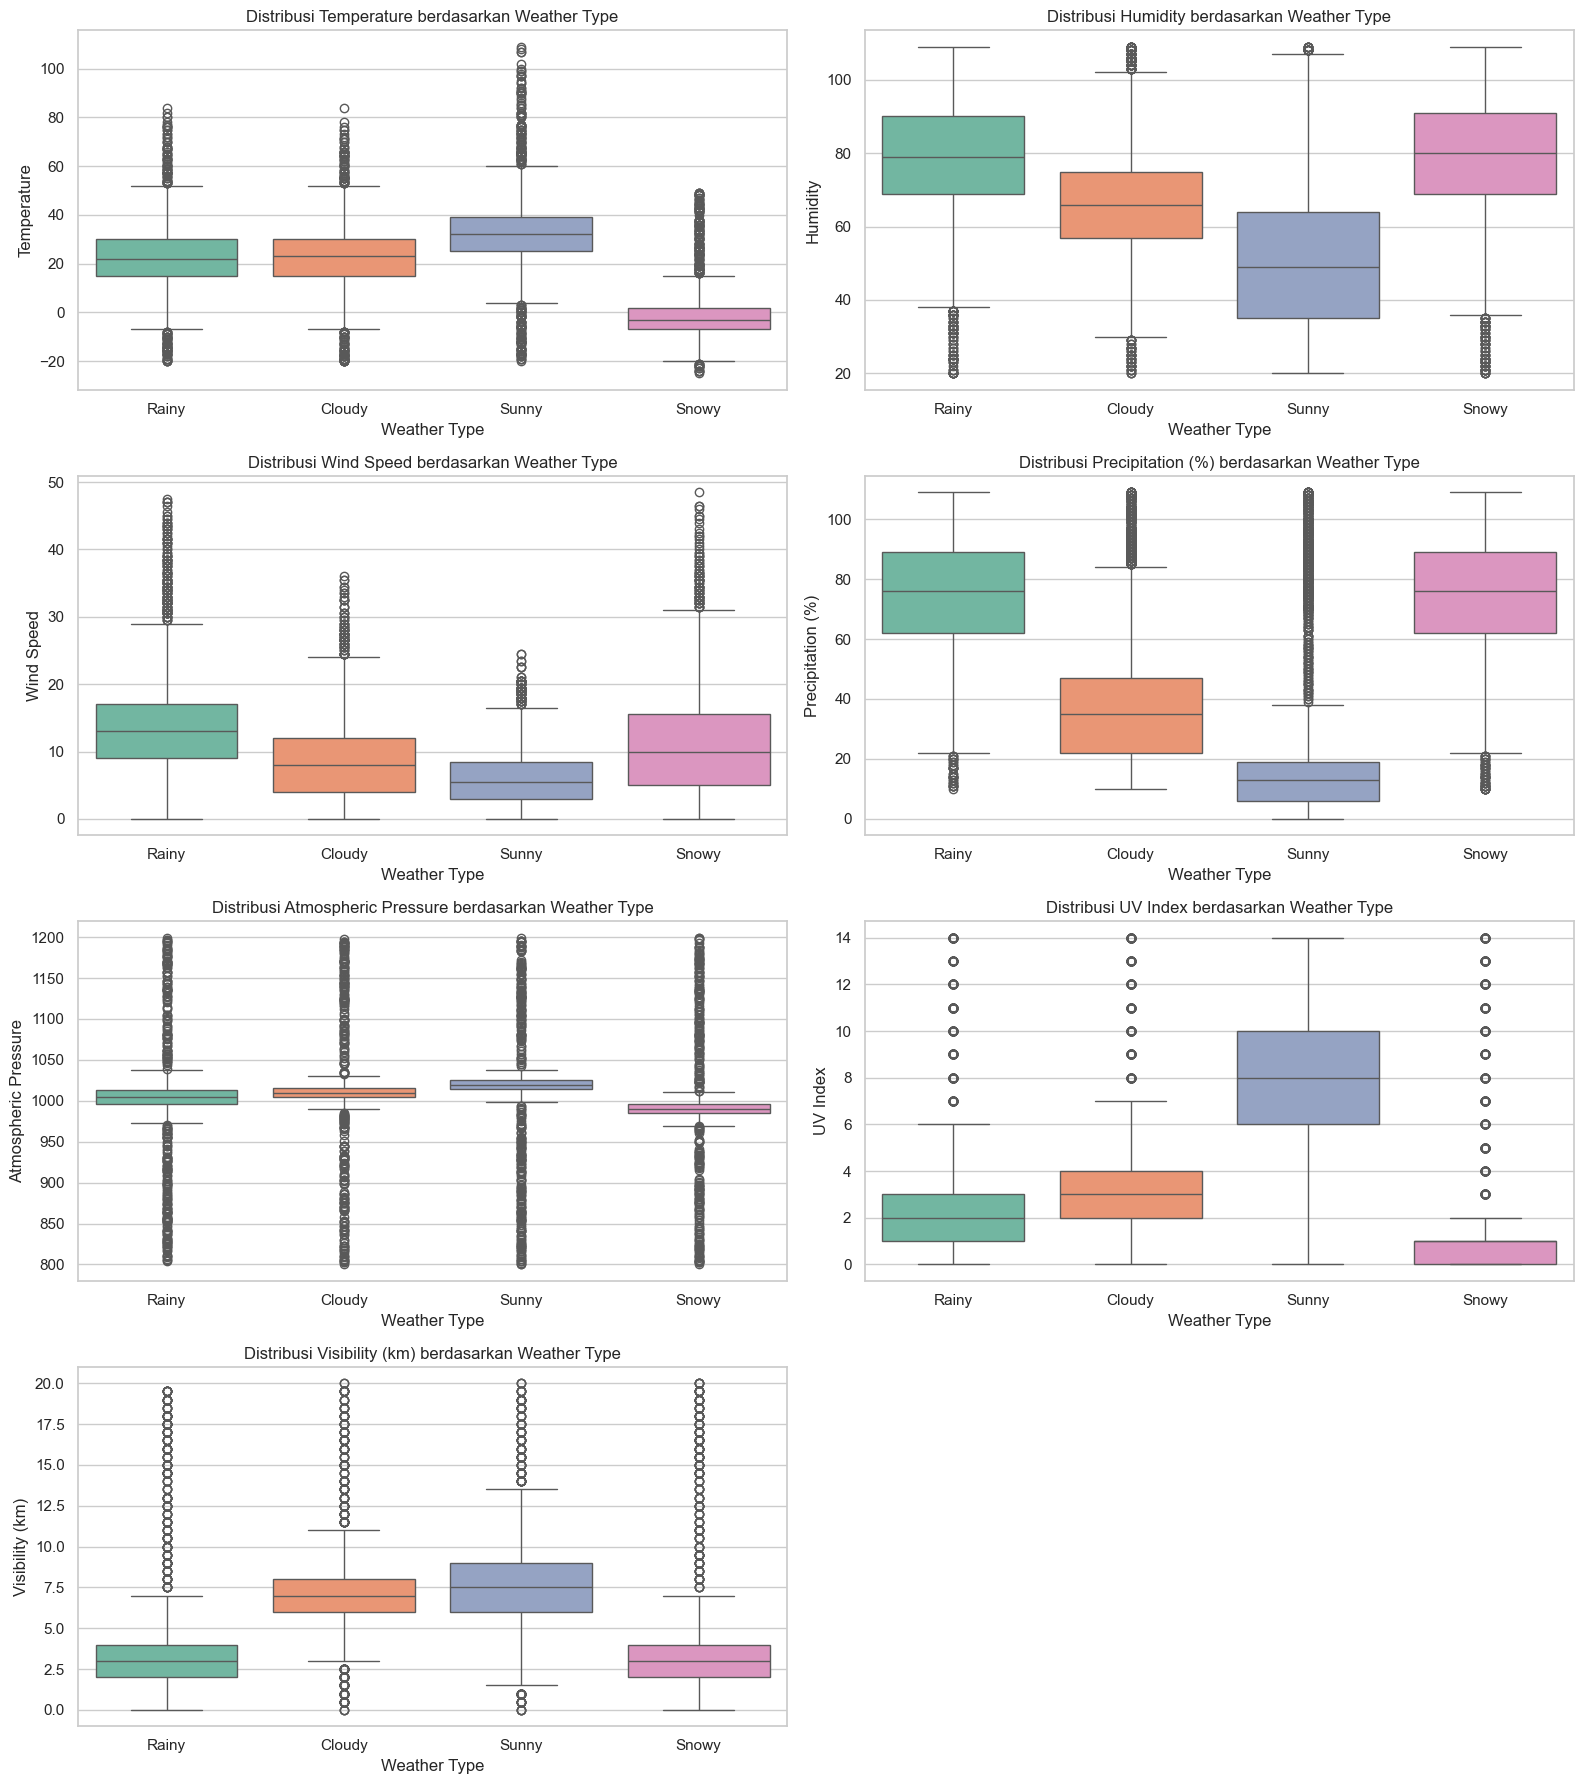

In [13]:
# Bivariate: Numerik vs Target - Melihat Fitur mana yang Membedakan Tiap Cuaca
plt.figure(figsize=(16, 18))
for i, col in enumerate(num_cols_univysis, 1):
    plt.subplot(4, 2, i)
    sns.boxplot(data=df, x=target, y=col, hue=target, palette='Set2')
    plt.title(f'Distribusi {col} berdasarkan {target}')
plt.tight_layout()
plt.show()

Insight: 
- Dari sini terlihat bahwa `weather_type` sangat dipengaruhi oleh beberapa fitur

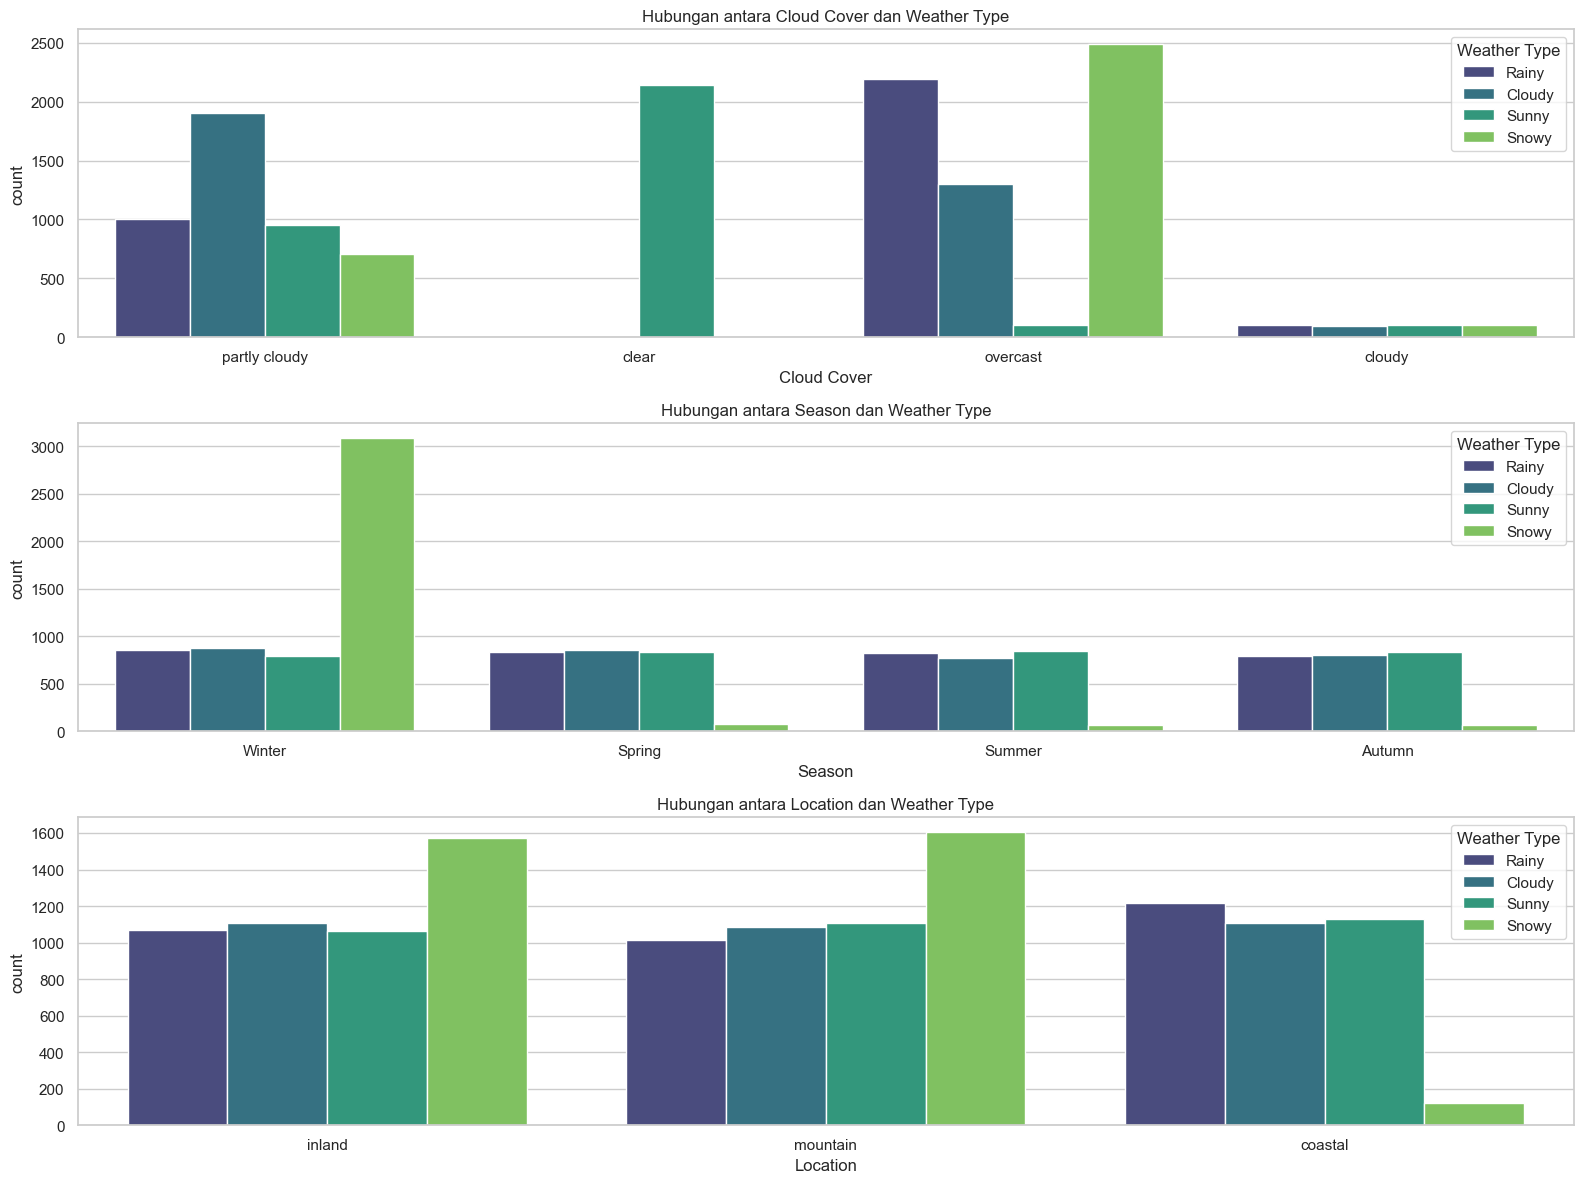

In [14]:
# Bivariate: Kategorikal vs Target - Melihat apakah lokasi atau musim didominasi cuaca tertentu
plt.figure(figsize=(16, 12))
for i, col in enumerate(cat_cols_bivysis, 1):
    plt.subplot(3, 1, i)
    sns.countplot(data=df, x=col, hue=target, palette='viridis')
    plt.title(f'Hubungan antara {col} dan {target}')
    plt.legend(title='Weather Type')
plt.tight_layout()
plt.show()

Insight:
- Di `coastal` atau `wilayah pesisir`, cuaca `snowy` sangat jarang terjadi
- Pada musim `Winter`, cuaca `Snowy` justru yang sangat sering terjadi

In [15]:
# Multivariate: Heatmap Korelasi - Melihat kolerasi antar fitur
# Konversi target ke kode angka sementara
df_encoded = df.copy()
df_encoded['Weather_Code'] = df_encoded[target].astype('category').cat.codes
numeric_df = df_encoded.select_dtypes(include=['float64', 'int64'])

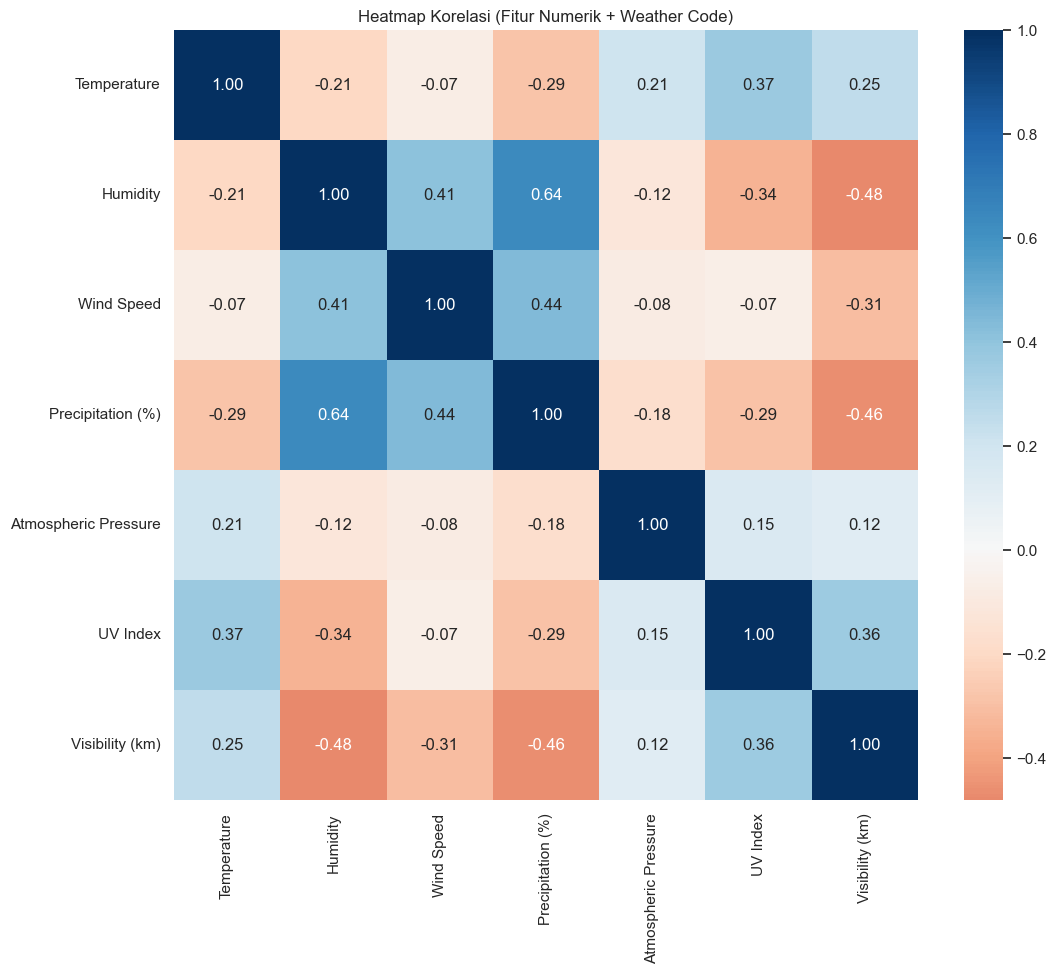

In [16]:
plt.figure(figsize=(12, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdBu', fmt='.2f', center=0)
plt.title('Heatmap Korelasi (Fitur Numerik + Weather Code)')
plt.show()

Insight:
- Terlihat bahwa antara fitur `Wind Speed` dengan `Precipitation` memiliki korelasi fitur yang cukup tinggi, yaitu sebesar **0,64**
- Sedangkan untuk korelasi fitur `Visibility dengan Wind Speed`, `Visibility dengan Precipitation` maupun sebaliknya, memiliki korelasi fitur yang rendah, bahkan hingga **menyentuh angka minus**

## Preprocessing Data

In [17]:
df_cleaned = df[(df['Humidity'] <= 100) & (df['Temperature'] <= 60)].copy()

In [18]:
# Diskritisasi (binning) untuk hitung entropi
df_bin = df_cleaned.copy()
num_features = [
    'Temperature',
    'Humidity',
    'Wind Speed',
    'Precipitation (%)',
    'Atmospheric Pressure',
    'UV Index',
    'Visibility (km)'
]
cat_features = ['Cloud Cover', 'Season', 'Location']

In [19]:
for col in num_features:
    df_bin[col] = pd.cut(df_bin[col], bins=3, labels=['Low', 'Medium', 'High'])

## Implementasi Kriteria Tugas

In [20]:
# Hitung Entropi
def calculate_entropy(data_labels):
    probs = data_labels.value_counts() / len(data_labels)
    return -sum(probs * np.log2(probs))

In [21]:
# Hitung Information Gain
def calculate_gain(df, attr, target):
    s_total = calculate_entropy(df[target])
    values = df[attr].unique()
    s_attr = 0
    for val in values:
        subset = df[df[attr] == val]
        s_attr += (len(subset) / len(df)) * calculate_entropy(subset[target])
    return s_total - s_attr

In [22]:
# Hitung Bobot W Setiap Fitur
all_orig_features = num_features + cat_features
weights_dict = {feat: calculate_gain(df_bin, feat, 'Weather Type') for feat in all_orig_features}

In [23]:
# Transformasi untuk modeling
df_final = pd.get_dummies(df_cleaned, columns=cat_features, dtype=int)
le = LabelEncoder()
df_final['Weather Type'] = le.fit_transform(df_final['Weather Type'])

In [24]:
X = df_final.drop('Weather Type', axis=1)
y = df_final['Weather Type']

In [25]:
# Scaling
scaler = MinMaxScaler()
X[num_features] = scaler.fit_transform(X[num_features])

In [26]:
# Aplikasikan Weight untuk WAKNN
X_weighted = X.copy()
for feat, w in weights_dict.items():
    cols = [c for c in X.columns if c.startswith(feat)]
    X_weighted[cols] = X_weighted[cols] * w

In [27]:
# Split Data untuk KNN dan WAKNN
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(X_weighted, y, test_size=0.2, random_state=42, stratify=y)

In [28]:
# Modeling & Optimization
k_val = 5

In [29]:
# Standar KNN
knn = KNeighborsClassifier(n_neighbors=k_val)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [30]:
# WAKNN (Semua Fitur)
waknn = KNeighborsClassifier(n_neighbors=k_val)
waknn.fit(X_train_w, y_train_w)
y_pred_waknn = waknn.predict(X_test_w)

In [31]:
# Seleksi Fitur
sorted_orig_features = sorted(weights_dict.items(), key=lambda item: item[1], reverse=True)

In [32]:
fs_results = []
for n in range(1, len(all_orig_features) + 1):
    top_n_orig = [f[0] for f in sorted_orig_features[:n]]
    top_cols = [c for c in X.columns if any(c.startswith(f) for f in top_n_orig)]
    
    fs_model = KNeighborsClassifier(n_neighbors=k_val)
    fs_model.fit(X_train_w[top_cols], y_train_w)
    acc = accuracy_score(y_test_w, fs_model.predict(X_test_w[top_cols]))
    fs_results.append({'Num_Features': n, 'Accuracy': acc})

In [33]:
fs_df = pd.DataFrame(fs_results)
best_n = fs_df.loc[fs_df['Accuracy'].idxmax(), 'Num_Features']

In [34]:
# Hasil
print('Information Gain (Weights)')
for k, v in sorted(weights_dict.items(), key=lambda item: item[1], reverse=True):
    print(f'{k:22}: {v:.4f}')

Information Gain (Weights)
Temperature           : 0.6427
Cloud Cover           : 0.5214
Precipitation (%)     : 0.4801
UV Index              : 0.4203
Visibility (km)       : 0.2951
Humidity              : 0.2909
Season                : 0.2820
Location              : 0.0872
Wind Speed            : 0.0809
Atmospheric Pressure  : 0.0003


In [35]:
print('Perbandingan Model')
print(f'Akurasi KNN Standar: {accuracy_score(y_test, y_pred_knn):.4f}')
print(f'Akurasi WAKNN tanpa seleksi fitur: {accuracy_score(y_test_w, y_pred_waknn):.4f}')
print(f'Akurasi WAKNN dengan seleksi fitur')
print(f'WAKNN (Top {int(best_n)}): {fs_df['Accuracy'].max():.4f}')

Perbandingan Model
Akurasi KNN Standar: 0.8982
Akurasi WAKNN tanpa seleksi fitur: 0.9030
Akurasi WAKNN dengan seleksi fitur
WAKNN (Top 6): 0.9105


In [36]:
print('Evaluasi Metrik')
print(classification_report(y_test_w, y_pred_waknn, target_names=le.classes_))

Evaluasi Metrik
              precision    recall  f1-score   support

      Cloudy       0.85      0.90      0.87       632
       Rainy       0.87      0.90      0.89       634
       Snowy       0.94      0.92      0.93       640
       Sunny       0.96      0.89      0.93       619

    accuracy                           0.90      2525
   macro avg       0.91      0.90      0.90      2525
weighted avg       0.91      0.90      0.90      2525

